# CattleEyeView Dataset Analysis

**Dataset:** CattleEyeView (detection subset)  
**Notebook:** `notebooks/dataset_analysis/analysis_cattleeyeview.ipynb`  
**Output:** `results/analysis/cattleeyeview_summary.json`

Derives all statistics from `data/raw/cattle-eye-view/` only. No pipeline outputs are read.


In [1]:
import sys, json, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

REPO_ROOT = Path("../..")
RAW = REPO_ROOT / "data" / "raw" / "cattle-eye-view" / "dataset" / "detect"
LABEL_ROOT = RAW / "labels"
IMG_ROOT = RAW / "images"
RESULTS_DIR = REPO_ROOT / "results" / "analysis"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SPLITS = ["train", "val", "test"]
CLASS_NAME = "cow"
CLASS_ID = 0


def iter_label_files(split: str):
    """Yield all .txt label files under labels/{split}/{video_id}/*.txt."""
    return sorted((LABEL_ROOT / split).rglob("*.txt"))


def find_image(split: str, video_id: str, stem: str) -> Path | None:
    base = IMG_ROOT / split / video_id / stem
    for ext in (".jpg", ".jpeg", ".png"):
        p = base.with_suffix(ext)
        if p.exists():
            return p
    return None


print("RAW path:", RAW.resolve())
for split in SPLITS:
    n_files = len(iter_label_files(split))
    videos = sorted(d.name for d in (LABEL_ROOT / split).iterdir() if d.is_dir())
    print(
        f"  {split:<6}: {n_files:>6,} label files across {len(videos)} video(s): {videos}"
    )

RAW path: /home/sakif/TXST/Thesis/cattle-vision-framework/data/raw/cattle-eye-view/dataset/detect
  train :  8,422 label files across 9 video(s): ['02.mp4', '03.mp4', '04.mp4', '06.mp4', '08.mp4', '11.mp4', '12.mp4', '13.mp4', '14.mp4']
  val   :  2,648 label files across 5 video(s): ['01.mp4', '05.mp4', '07.mp4', '09.mp4', '10.mp4']
  test  :  2,648 label files across 5 video(s): ['01.mp4', '05.mp4', '07.mp4', '09.mp4', '10.mp4']


---

## 1. Dataset Overview

**Origin:** CattleEyeView is a multi-task top-down-view cattle dataset collected at a loading ramp and holding facility. Video footage was captured from a fixed overhead camera positioned directly above a livestock chute, recording cattle as they move through individually. The dataset supports detection, tracking, counting, pose estimation, and instance segmentation.

**Paper:** _"CattleEyeView: A Multi-task Top-down View Cattle Dataset for Smarter Precision Livestock Farming"_ (Ong et al., 2023 IEEE VCIP). Released by the Singapore University of Technology and Design (SUTD) and AnimalEyeQ.

**License:** Academic use (available at github.com/AnimalEyeQ/CattleEyeView).

**Annotation format:** YOLO `.txt` per frame, nested one level deeper than flat YOLO:

```
detect/labels/{split}/{video_id}/{frame}.txt
```

Each line: `<class_id> <x_center> <y_center> <width> <height>` (all normalized 0–1). Single class: `cow` (ID 0).

**Split structure:** 14 unique videos — 9 in train, 5 in test/val. The val and test splits reference the **same** 5 videos and the **same** label files.

**Distinctive visual characteristics:**

- Top-down overhead view of a narrow livestock chute/ramp — cattle appear elongated and foreshortened
- Multiple cattle breeds and coat colors (unlike the Holstein-only datasets)
- High cattle density per frame; significant occlusion as animals queue through the chute
- Outdoor setting with variable lighting

**Role in thesis pipeline (Phase 8):**

- **Detection mAP** — OOD generalization test for RF-DETR trained on CBVD-5 + CVB
- **Mask IoU** — evaluate SAM2 segmentation quality on top-down footage
- **IDF1** — evaluate OC-SORT tracking on overhead multi-cattle sequences
- **No behavior labels** — behavior classification is out of scope


---

## 2. Data Inventory


In [2]:
split_stats = {}

for split in SPLITS:
    n_frames = 0
    n_boxes = 0
    boxes_per_frame = []
    n_missing_img = 0
    videos = sorted(d.name for d in (LABEL_ROOT / split).iterdir() if d.is_dir())

    for txt in iter_label_files(split):
        video_id = txt.parent.name
        img = find_image(split, video_id, txt.stem)
        if img is None:
            n_missing_img += 1

        lines = [l.strip() for l in txt.read_text().splitlines() if l.strip()]
        n_frames += 1
        n_boxes += len(lines)
        boxes_per_frame.append(len(lines))

    split_stats[split] = {
        "n_frames": n_frames,
        "n_boxes": n_boxes,
        "bpf": boxes_per_frame,
        "n_missing_img": n_missing_img,
        "videos": videos,
    }

# val and test reference the same files — deduplicate for total unique count
total_unique_frames = split_stats["train"]["n_frames"] + split_stats["val"]["n_frames"]
total_unique_boxes = split_stats["train"]["n_boxes"] + split_stats["val"]["n_boxes"]

print(
    f"{'Split':<8} {'Videos':>8} {'Frames':>8} {'Boxes':>8} {'Avg bpf':>9} {'Missing img':>12}"
)
print("-" * 60)
for split in SPLITS:
    s = split_stats[split]
    bpf = s["bpf"]
    print(
        f"{split:<8} {len(s['videos']):>8} {s['n_frames']:>8,} {s['n_boxes']:>8,} "
        f"{np.mean(bpf):>9.2f} {s['n_missing_img']:>12,}"
    )
print("-" * 60)
print(
    f"{'UNIQUE':<8} {'14':>8} {total_unique_frames:>8,} {total_unique_boxes:>8,} "
    f"{'(val==test)':>22}"
)
print()
print("Note: val and test reference the same 5 videos with identical label files.")
print("      'UNIQUE' counts train + val once (deduplicates test).")
print()
print("Label format:  YOLO .txt — <class_id> <x_center> <y_center> <width> <height>")
print("                          (normalized 0–1 relative to frame dimensions)")
print("Single class:  'cow' (ID 0)")
print("Path depth:    detect/labels/{split}/{video_id}/{frame}.txt  (nested 1 level)")

Split      Videos   Frames    Boxes   Avg bpf  Missing img
------------------------------------------------------------
train           9    8,422   17,144      2.04          831
val             5    2,648    6,910      2.61          158
test            5    2,648    6,910      2.61          158
------------------------------------------------------------
UNIQUE         14   11,070   24,054            (val==test)

Note: val and test reference the same 5 videos with identical label files.
      'UNIQUE' counts train + val once (deduplicates test).

Label format:  YOLO .txt — <class_id> <x_center> <y_center> <width> <height>
                          (normalized 0–1 relative to frame dimensions)
Single class:  'cow' (ID 0)
Path depth:    detect/labels/{split}/{video_id}/{frame}.txt  (nested 1 level)


---

## 3. Sample Image Visualization


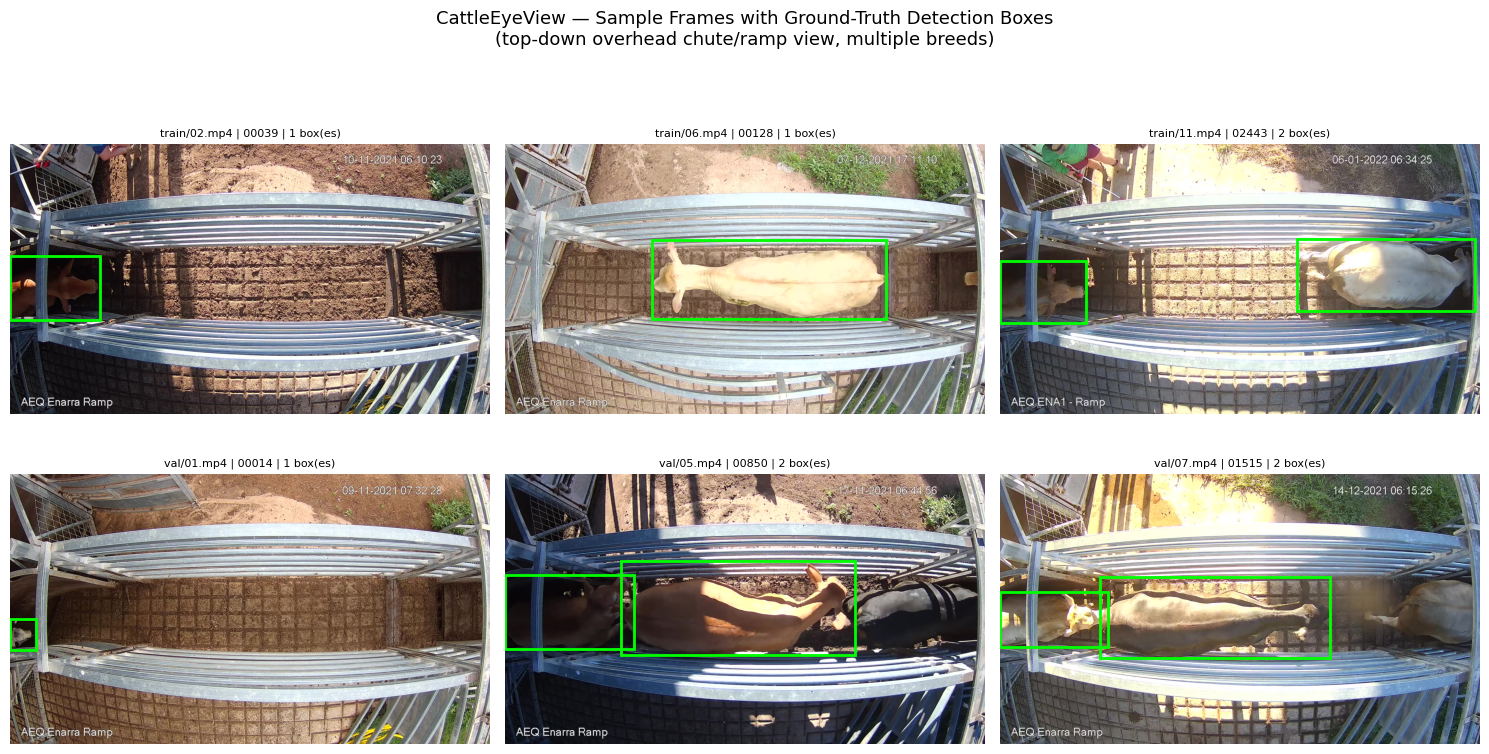

Saved: results/analysis/cattleeyeview_sample_frames.png


In [3]:
# Pick 3 frames from train and 3 from val, evenly spaced, with matched images
sample_entries = []
for split in ["train", "val"]:
    label_files = iter_label_files(split)
    # only files that have a matching image
    paired = [
        (txt, find_image(split, txt.parent.name, txt.stem))
        for txt in label_files
        if find_image(split, txt.parent.name, txt.stem) is not None
    ]
    step = max(1, len(paired) // 3)
    for txt, img_path in paired[::step][:3]:
        sample_entries.append((split, txt.parent.name, txt, img_path))

n_samples = len(sample_entries)
n_cols = 3
n_rows = (n_samples + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
fig.suptitle(
    "CattleEyeView — Sample Frames with Ground-Truth Detection Boxes\n"
    "(top-down overhead chute/ramp view, multiple breeds)",
    fontsize=13,
    y=1.01,
)

for ax, (split, video_id, txt, img_path) in zip(axes.flat, sample_entries):
    img = Image.open(img_path)
    W, H = img.size
    lines = [l.strip() for l in txt.read_text().splitlines() if l.strip()]

    ax.imshow(img)
    for line in lines:
        parts = line.split()
        _, xc, yc, bw, bh = (
            float(parts[0]),
            float(parts[1]),
            float(parts[2]),
            float(parts[3]),
            float(parts[4]),
        )
        x1 = (xc - bw / 2) * W
        y1 = (yc - bh / 2) * H
        rect = plt.Rectangle(
            (x1, y1), bw * W, bh * H, fill=False, edgecolor="lime", linewidth=2
        )
        ax.add_patch(rect)

    ax.set_title(f"{split}/{video_id} | {txt.stem} | {len(lines)} box(es)", fontsize=8)
    ax.axis("off")

for ax in axes.flat[n_samples:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "cattleeyeview_sample_frames.png", dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved: results/analysis/cattleeyeview_sample_frames.png")

---

## 4. Annotation Format


In [4]:
# Find a label file with multiple boxes for a complete example
sample_txt = None
for txt in iter_label_files("train"):
    lines = txt.read_text().strip().splitlines()
    if len(lines) >= 3:
        sample_txt = txt
        sample_lines = lines
        break

print(f"=== YOLO label file: {sample_txt.relative_to(LABEL_ROOT)} ===")
print()
print(f"  Path depth: labels / {{split}} / {{video_id}} / {{frame}}.txt")
print(
    f"  This file:  labels / train / {sample_txt.parent.name} / {sample_txt.stem}.txt"
)
print()
print(f"  File contents ({len(sample_lines)} boxes):")
for i, line in enumerate(sample_lines):
    parts = line.split()
    print(f"  Line {i}: {line}")
    print(
        f"           → class_id={parts[0]}  x_center={parts[1]}  y_center={parts[2]}  width={parts[3]}  height={parts[4]}"
    )
print()
print("Field definitions (YOLO detection format):")
print("  class_id  — always 0 ('cow'); single-class dataset")
print("  x_center  — normalized horizontal center of box (0–1 relative to frame width)")
print("  y_center  — normalized vertical center of box (0–1 relative to frame height)")
print("  width     — normalized box width (0–1 relative to frame width)")
print("  height    — normalized box height (0–1 relative to frame height)")
print()
print("Corresponding image:")
print(f"  images / train / {sample_txt.parent.name} / {sample_txt.stem}.jpg")
print()
print("Class map (from cattleeyeview_detect.yaml):")
print("  {0: cow}  — single detection class across the full dataset")

=== YOLO label file: train/02.mp4/01679.txt ===

  Path depth: labels / {split} / {video_id} / {frame}.txt
  This file:  labels / train / 02.mp4 / 01679.txt

  File contents (3 boxes):
  Line 0: 0 0.362326 0.490046 0.42963 0.338272
           → class_id=0  x_center=0.362326  y_center=0.490046  width=0.42963  height=0.338272
  Line 1: 0 0.043999 0.548846 0.087998 0.2
           → class_id=0  x_center=0.043999  y_center=0.548846  width=0.087998  height=0.2
  Line 2: 0 0.749327 0.522545 0.39359 0.265527
           → class_id=0  x_center=0.749327  y_center=0.522545  width=0.39359  height=0.265527

Field definitions (YOLO detection format):
  class_id  — always 0 ('cow'); single-class dataset
  x_center  — normalized horizontal center of box (0–1 relative to frame width)
  y_center  — normalized vertical center of box (0–1 relative to frame height)
  width     — normalized box width (0–1 relative to frame width)
  height    — normalized box height (0–1 relative to frame height)

Correspondi

---

## 5. Class Distribution (Detection Box Counts)


In [5]:
print("Detection annotation class distribution — 'cow' boxes per split")
print()
print(
    f"{'Split':<8} {'Videos':>8} {'Frames':>8} {'Boxes':>8} {'Avg bpf':>10} {'Max bpf':>8}"
)
print("-" * 55)
for split in SPLITS:
    s = split_stats[split]
    bpf = s["bpf"]
    print(
        f"{split:<8} {len(s['videos']):>8} {s['n_frames']:>8,} {s['n_boxes']:>8,} "
        f"{np.mean(bpf):>10.2f} {max(bpf):>8}"
    )
print("-" * 55)
print(
    f"{'UNIQUE':<8} {'14':>8} {total_unique_frames:>8,} {total_unique_boxes:>8,}"
    f" {'(val==test)':>20}"
)
print()
print("Note: All boxes belong to the single class 'cow' (class_id 0).")
print("      No behavior labels are present in this dataset.")

Detection annotation class distribution — 'cow' boxes per split

Split      Videos   Frames    Boxes    Avg bpf  Max bpf
-------------------------------------------------------
train           9    8,422   17,144       2.04        5
val             5    2,648    6,910       2.61        9
test            5    2,648    6,910       2.61        9
-------------------------------------------------------
UNIQUE         14   11,070   24,054          (val==test)

Note: All boxes belong to the single class 'cow' (class_id 0).
      No behavior labels are present in this dataset.


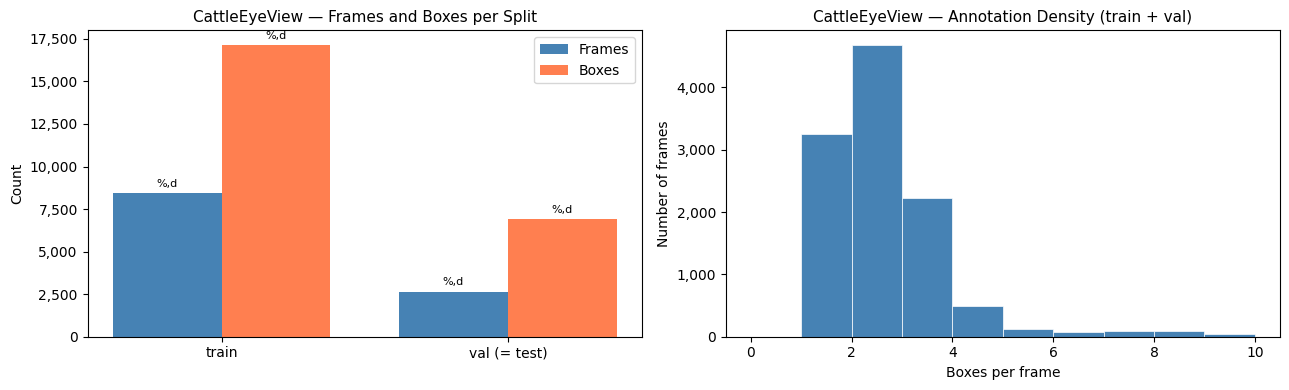

Saved: results/analysis/cattleeyeview_class_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: frames and boxes per split (train vs. val, ignoring duplicate test)
ax = axes[0]
display_splits = ["train", "val (= test)"]
frame_counts = [
    split_stats["train"]["n_frames"],
    split_stats["val"]["n_frames"],
]
box_counts = [
    split_stats["train"]["n_boxes"],
    split_stats["val"]["n_boxes"],
]
x = np.arange(len(display_splits))
width = 0.38
b1 = ax.bar(x - width / 2, frame_counts, width, label="Frames", color="steelblue")
b2 = ax.bar(x + width / 2, box_counts, width, label="Boxes", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(display_splits, fontsize=10)
ax.set_ylabel("Count")
ax.set_title("CattleEyeView — Frames and Boxes per Split", fontsize=11)
ax.legend()
ax.bar_label(b1, fmt="%,d", fontsize=8, padding=3)
ax.bar_label(b2, fmt="%,d", fontsize=8, padding=3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))

# Right: histogram of boxes-per-frame (annotation density) for train+val
ax2 = axes[1]
all_bpf = split_stats["train"]["bpf"] + split_stats["val"]["bpf"]
max_bpf = max(all_bpf)
ax2.hist(
    all_bpf,
    bins=range(0, max_bpf + 2),
    color="steelblue",
    edgecolor="white",
    linewidth=0.5,
)
ax2.set_xlabel("Boxes per frame", fontsize=10)
ax2.set_ylabel("Number of frames", fontsize=10)
ax2.set_title("CattleEyeView — Annotation Density (train + val)", fontsize=11)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "cattleeyeview_class_distribution.png", dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved: results/analysis/cattleeyeview_class_distribution.png")

---

## 6. Resolution & Quality


In [7]:
# Resolution from a sample image (YAML states imgsz: [1920, 1080])
sample_img_path = next(
    p
    for txt in iter_label_files("train")
    for p in [find_image("train", txt.parent.name, txt.stem)]
    if p is not None
)
sample_img = Image.open(sample_img_path)
W_img, H_img = sample_img.size

print(f"Sample image: {sample_img_path.relative_to(IMG_ROOT)}")
print(f"Resolution:   {W_img}×{H_img} px (W×H)")
print(f"(Confirmed by cattleeyeview_detect.yaml: imgsz: [1920, 1080])")
print()

# Bounding box size statistics from train + val label files
box_widths_px = []
box_heights_px = []
box_areas_px = []

for split in ["train", "val"]:
    for txt in iter_label_files(split):
        for line in txt.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            bw = float(parts[3]) * W_img
            bh = float(parts[4]) * H_img
            box_widths_px.append(bw)
            box_heights_px.append(bh)
            box_areas_px.append(bw * bh)

img_area = W_img * H_img
print("Bounding box size statistics (train + val, pixels):")
print(
    f"  Box width  — min={min(box_widths_px):.0f}  max={max(box_widths_px):.0f}  mean={np.mean(box_widths_px):.1f}  median={np.median(box_widths_px):.1f}"
)
print(
    f"  Box height — min={min(box_heights_px):.0f}  max={max(box_heights_px):.0f}  mean={np.mean(box_heights_px):.1f}  median={np.median(box_heights_px):.1f}"
)
print(
    f"  Box area   — min={min(box_areas_px):.0f}  max={max(box_areas_px):.0f}  mean={np.mean(box_areas_px):.0f}  median={np.median(box_areas_px):.0f}"
)
print(f"  Avg box as % of image area: {100 * np.mean(box_areas_px) / img_area:.1f}%")

Sample image: train/02.mp4/00039.jpg
Resolution:   1920×1080 px (W×H)
(Confirmed by cattleeyeview_detect.yaml: imgsz: [1920, 1080])

Bounding box size statistics (train + val, pixels):
  Box width  — min=26  max=1141  mean=658.1  median=717.0
  Box height — min=54  max=665  mean=299.2  median=303.7
  Box area   — min=1384  max=471890  mean=207224  median=228164
  Avg box as % of image area: 10.0%


In [8]:
# Image / label pairing check
print("Image pairing check (label files with no matching .jpg/.png):")
print()
for split in SPLITS:
    s = split_stats[split]
    pct = 100 * s["n_missing_img"] / s["n_frames"] if s["n_frames"] > 0 else 0
    status = "✅" if s["n_missing_img"] == 0 else "⚠️ "
    print(
        f"  {status} {split:<6}: {s['n_missing_img']:,} missing images "
        f"out of {s['n_frames']:,} label files ({pct:.1f}%)"
    )
print()
print(
    "Note: Missing images are expected — the released images/ folder is a subset of\n"
    "      all labeled frames (dataset ships with images.tar.gz; only extracted\n"
    "      images appear in detect/images/). Evaluation uses only paired frames."
)

Image pairing check (label files with no matching .jpg/.png):

  ⚠️  train : 831 missing images out of 8,422 label files (9.9%)
  ⚠️  val   : 158 missing images out of 2,648 label files (6.0%)
  ⚠️  test  : 158 missing images out of 2,648 label files (6.0%)

Note: Missing images are expected — the released images/ folder is a subset of
      all labeled frames (dataset ships with images.tar.gz; only extracted
      images appear in detect/images/). Evaluation uses only paired frames.


---

## 7. Evaluation Scope

> **This dataset has no behavior labels. It is used for detection, segmentation, and tracking evaluation in Phase 8.**

| Evaluation task         | In scope | Notes                                                            |
| ----------------------- | -------- | ---------------------------------------------------------------- |
| Detection mAP           | ✅ Yes   | OOD test for RF-DETR trained on CBVD-5 + CVB                     |
| Mask IoU                | ✅ Yes   | Evaluate SAM2 segmentation quality on top-down footage           |
| IDF1 (tracking)         | ✅ Yes   | Evaluate OC-SORT on overhead high-density multi-cattle sequences |
| Behavior classification | ❌ No    | No behavior labels present                                       |
| Activity budgets        | ❌ No    | No behavior labels present                                       |
| Training                | ❌ No    | Not used for model training                                      |

**Val == Test note:** The `val` and `test` splits reference the same 5 videos with identical label files. For Phase 8, use the `test` split for final evaluation and `val` for any threshold tuning (they are the same data, so do not tune then report on test — use one or the other).

**Split benchmark from the paper:** The paper reports results on the 5 held-out test videos (IDs 01, 05, 07, 09, 10). This project mirrors that protocol.

**Why this dataset matters for Phase 8:**  
CattleEyeView provides the most demanding OOD challenge in the Phase 8 suite — top-down chute footage with high cattle density, occlusion, and multiple breeds. Performance here directly quantifies viewpoint, density, and breed generalization.


In [9]:
train_videos = sorted(d.name for d in (LABEL_ROOT / "train").iterdir() if d.is_dir())
test_videos = sorted(d.name for d in (LABEL_ROOT / "test").iterdir() if d.is_dir())

print("Evaluation scope summary:")
print()
print(
    "  Dataset role:         Phase 8 OOD detection + segmentation + tracking evaluation"
)
print("  Behavior labels:      None")
print("  Detection class:      'cow' (ID 0) → directly compatible with RF-DETR class 0")
print(
    f"  Train split:          {len(train_videos)} videos  {split_stats['train']['n_frames']:,} frames  {split_stats['train']['n_boxes']:,} boxes"
)
print(
    f"  Test split:           {len(test_videos)} videos  {split_stats['test']['n_frames']:,} frames  {split_stats['test']['n_boxes']:,} boxes"
)
print(f"  Val split:            identical to test (same videos, same labels)")
print()
print(f"  Train videos: {train_videos}")
print(f"  Test videos:  {test_videos}")
print()
print("  OOD challenge factors:")
print("    1. Camera viewpoint — overhead chute/ramp vs. side-view in training data")
print("    2. Multiple breeds   — not restricted to Holstein-Friesian")
print("    3. High density      — multiple overlapping cattle per frame (avg 2+ boxes)")
print("    4. Environment       — outdoor loading ramp vs. indoor barn")

Evaluation scope summary:

  Dataset role:         Phase 8 OOD detection + segmentation + tracking evaluation
  Behavior labels:      None
  Detection class:      'cow' (ID 0) → directly compatible with RF-DETR class 0
  Train split:          9 videos  8,422 frames  17,144 boxes
  Test split:           5 videos  2,648 frames  6,910 boxes
  Val split:            identical to test (same videos, same labels)

  Train videos: ['02.mp4', '03.mp4', '04.mp4', '06.mp4', '08.mp4', '11.mp4', '12.mp4', '13.mp4', '14.mp4']
  Test videos:  ['01.mp4', '05.mp4', '07.mp4', '09.mp4', '10.mp4']

  OOD challenge factors:
    1. Camera viewpoint — overhead chute/ramp vs. side-view in training data
    2. Multiple breeds   — not restricted to Holstein-Friesian
    3. High density      — multiple overlapping cattle per frame (avg 2+ boxes)
    4. Environment       — outdoor loading ramp vs. indoor barn


---

## 8. Preprocessing Gap Analysis


In [10]:
print("Preprocessing steps required before CattleEyeView enters the Phase 8 pipeline:")
print()
print("1. Verify / unpack images")
print(
    "   - images.tar.gz ships the full image set. Confirm detect/images/ is complete."
)
print(
    f"   - {split_stats['train']['n_missing_img']:,} train frames and "
    f"{split_stats['val']['n_missing_img']:,} val frames currently have no matching image."
)
print("   - Only paired frames (label + image both present) are used in evaluation.")
print()
print("2. No annotation format conversion needed for RF-DETR")
print("   - Labels are already in YOLO format; RF-DETR evaluation can ingest directly.")
print("   - Denormalize boxes: x_px = x_center * W, y_px = y_center * H, etc.")
print()
print("3. Treat val == test appropriately")
print("   - Val and test are identical. Choose one for final mAP / IDF1 reporting.")
print("   - Do not tune on val and then report test as an independent held-out result.")
print()
print("4. Detection inference (script 06_run_detection.sh)")
print("   - Run RF-DETR on test images; compute mAP against ground-truth YOLO boxes.")
print()
print("5. SAM2 segmentation (script 07_run_segmentation.sh)")
print("   - Propagate SAM2 masks on test video sequences.")
print("   - Compute Mask IoU against any available segmentation ground truth.")
print(
    "   - Note: CattleEyeView has a segment/ task; check segment/labels/ for mask GT."
)
print()
print("6. Tracking evaluation (script 08_run_tracking.sh)")
print("   - Run OC-SORT on per-video frame sequences in the test split.")
print("   - Videos provide natural temporal structure for IDF1 evaluation.")
print()
print(
    "7. No behavior labels — no tubelet generation or behavior classification needed."
)

Preprocessing steps required before CattleEyeView enters the Phase 8 pipeline:

1. Verify / unpack images
   - images.tar.gz ships the full image set. Confirm detect/images/ is complete.
   - 831 train frames and 158 val frames currently have no matching image.
   - Only paired frames (label + image both present) are used in evaluation.

2. No annotation format conversion needed for RF-DETR
   - Labels are already in YOLO format; RF-DETR evaluation can ingest directly.
   - Denormalize boxes: x_px = x_center * W, y_px = y_center * H, etc.

3. Treat val == test appropriately
   - Val and test are identical. Choose one for final mAP / IDF1 reporting.
   - Do not tune on val and then report test as an independent held-out result.

4. Detection inference (script 06_run_detection.sh)
   - Run RF-DETR on test images; compute mAP against ground-truth YOLO boxes.

5. SAM2 segmentation (script 07_run_segmentation.sh)
   - Propagate SAM2 masks on test video sequences.
   - Compute Mask IoU again

---

## 9. Summary JSON + Self-Consistency Check


In [11]:
summary = {
    "dataset": "cattleeyeview",
    "total_images_or_frames": total_unique_frames,
    "total_annotations": total_unique_boxes,
    "splits": {
        "train": split_stats["train"]["n_frames"],
        "val": split_stats["val"]["n_frames"],
        "test": split_stats["test"]["n_frames"],
    },
    "class_distribution": {"cow": total_unique_boxes},
    "resolution": {"width": W_img, "height": H_img},
    "has_behavior_labels": False,
    "evaluation_scope": ["detection_map", "mask_iou", "tracking_idf1"],
}

# Schema validation
required_keys = [
    "dataset",
    "total_images_or_frames",
    "total_annotations",
    "splits",
    "class_distribution",
    "resolution",
    "has_behavior_labels",
    "evaluation_scope",
]
missing_keys = [k for k in required_keys if k not in summary]
assert not missing_keys, f"Missing schema keys: {missing_keys}"

non_int = {
    k: v
    for k, v in summary["class_distribution"].items()
    if not isinstance(v, int) or v <= 0
}
assert not non_int, f"class_distribution has invalid values: {non_int}"

out_path = RESULTS_DIR / "cattleeyeview_summary.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Summary JSON:")
print(json.dumps(summary, indent=2))
print(f"\n✅ Saved: {out_path}")

Summary JSON:
{
  "dataset": "cattleeyeview",
  "total_images_or_frames": 11070,
  "total_annotations": 24054,
  "splits": {
    "train": 8422,
    "val": 2648,
    "test": 2648
  },
  "class_distribution": {
    "cow": 24054
  },
  "resolution": {
    "width": 1920,
    "height": 1080
  },
  "has_behavior_labels": false,
  "evaluation_scope": [
    "detection_map",
    "mask_iou",
    "tracking_idf1"
  ]
}

✅ Saved: ../../results/analysis/cattleeyeview_summary.json


In [12]:
# Self-consistency check against known CattleEyeView dataset statistics
total_unique_videos = len(
    set(
        d.name for split in SPLITS for d in (LABEL_ROOT / split).iterdir() if d.is_dir()
    )
)

print("Self-consistency check:")
print("=" * 75)

checks = [
    (
        "Total unique videos",
        total_unique_videos,
        14,
        "== 14 (9 train + 5 test/val, per paper)",
    ),
    (
        "Train videos",
        len(split_stats["train"]["videos"]),
        9,
        "== 9",
    ),
    (
        "Val videos",
        len(split_stats["val"]["videos"]),
        5,
        "== 5",
    ),
    (
        "Test videos",
        len(split_stats["test"]["videos"]),
        5,
        "== 5",
    ),
    (
        "Val == Test frames",
        int(split_stats["val"]["n_frames"] == split_stats["test"]["n_frames"]),
        1,
        "val and test are identical",
    ),
    (
        "Val == Test boxes",
        int(split_stats["val"]["n_boxes"] == split_stats["test"]["n_boxes"]),
        1,
        "val and test are identical",
    ),
    (
        "Resolution width",
        W_img,
        1920,
        "== 1920 px (from yaml: imgsz: [1920, 1080])",
    ),
    (
        "Resolution height",
        H_img,
        1080,
        "== 1080 px",
    ),
    (
        "Distinct classes",
        len(summary["class_distribution"]),
        1,
        "== 1 ('cow' only)",
    ),
    (
        "has_behavior_labels",
        int(summary["has_behavior_labels"]),
        0,
        "== False (detection only)",
    ),
    (
        "Total unique frames > 0",
        int(total_unique_frames > 0),
        1,
        "at least one labeled frame found",
    ),
]

all_ok = True
for name, computed, expected, note in checks:
    ok = computed == expected
    status = "✅" if ok else "⚠️ "
    if not ok:
        all_ok = False
    print(f"{status} {name:<40} computed={computed:>7}  expected={expected:>7}  {note}")

print()
if all_ok:
    print("✅ All checks passed.")
else:
    print("⚠️  Some checks failed — review the values above.")

Self-consistency check:
✅ Total unique videos                      computed=     14  expected=     14  == 14 (9 train + 5 test/val, per paper)
✅ Train videos                             computed=      9  expected=      9  == 9
✅ Val videos                               computed=      5  expected=      5  == 5
✅ Test videos                              computed=      5  expected=      5  == 5
✅ Val == Test frames                       computed=      1  expected=      1  val and test are identical
✅ Val == Test boxes                        computed=      1  expected=      1  val and test are identical
✅ Resolution width                         computed=   1920  expected=   1920  == 1920 px (from yaml: imgsz: [1920, 1080])
✅ Resolution height                        computed=   1080  expected=   1080  == 1080 px
✅ Distinct classes                         computed=      1  expected=      1  == 1 ('cow' only)
✅ has_behavior_labels                      computed=      0  expected=      0  == F